In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('Student_Performance.csv')

In [14]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [6]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [15]:
x=df.iloc[:,:-1].values
y=df.iloc[:,-1].values
print(x.shape,y.shape)

(10000, 5) (10000,)


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), [2])
    ],
    remainder='passthrough'
)

x = ct.fit_transform(x)

In [17]:
print(x.shape)

(10000, 6)


In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [19]:
print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)

(8000, 6) (2000, 6)
(8000,) (2000,)


In [20]:
from sklearn.linear_model import LinearRegression
regressor  = LinearRegression()
regressor.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = regressor.predict(x_test)
print(y_pred)

[50.45128503 53.09379171 78.24502652 ... 64.56863194 25.89718776
 18.82598463]


In [22]:
print(regressor.predict([[0, 1, 7, 95, 8, 4]]))

[87.91153489]


In [23]:
print(regressor.predict([[1, 0, 7, 95, 8, 4]]))

[87.24623142]


In [24]:
print(regressor.coef_)
print(regressor.intercept_)

[-0.33265173  0.33265173  2.85191442  1.01886667  0.47682996  0.18776637]
-33.742556490415836


In [25]:
print('score:{}'.format(regressor.score(x_test,y_test)))

score:0.9880686410711422


In [27]:
plt.style.use('fivethirtyeight')

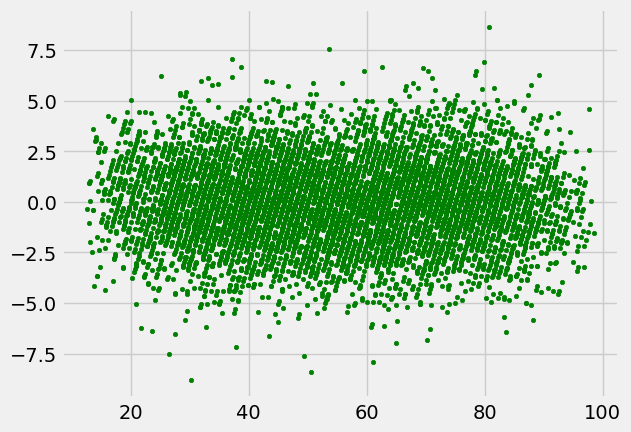

In [28]:
plt.scatter(regressor.predict(x_train),regressor.predict(x_train)-y_train,color='green',s=10,label='Train data')

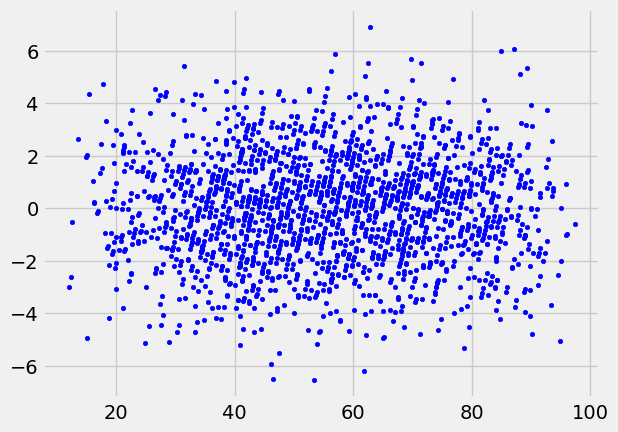

In [29]:
plt.scatter(regressor.predict(x_test),regressor.predict(x_test)-y_test,color='blue',s=10,label='test data')

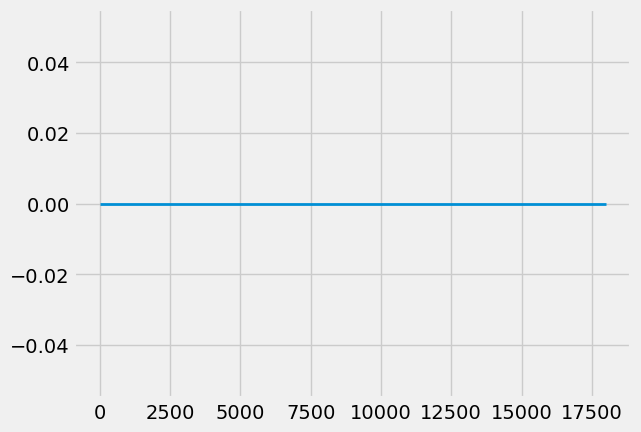

In [30]:
plt.hlines(y=0,xmin=0,xmax=18000,linewidth=2)

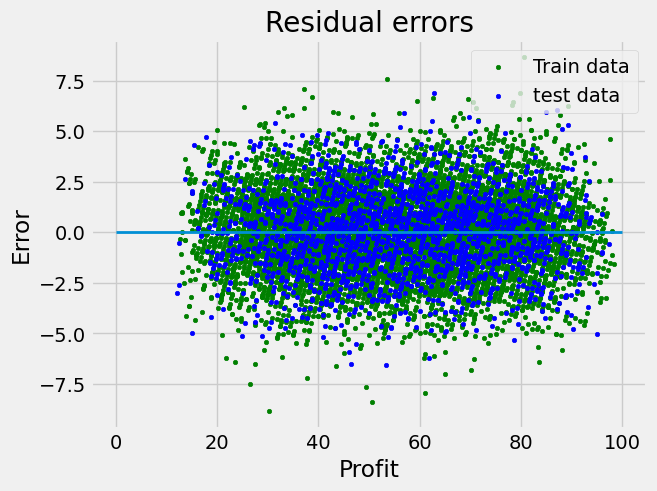

In [31]:
plt.style.use('fivethirtyeight')
plt.scatter(regressor.predict(x_train),regressor.predict(x_train)-y_train,color='green',s=10,label='Train data')
plt.scatter(regressor.predict(x_test),regressor.predict(x_test)-y_test,color='blue',s=10,label='test data')
plt.hlines(y=0,xmin=0,xmax=100,linewidth=2)
plt.legend(loc='upper right')
plt.title("Residual errors")
plt.xlabel("Profit")
plt.ylabel("Error")
plt.show()

In [32]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

0.9880686410711422
